In [ ]:
#Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for modelling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')


# ✈️ Airline Customer Churn Prediction: Model Development and Deployment

This notebook builds machine learning models to predict customer churn. We'll train multiple algorithms, evaluate their performance on a holdout test set, tune hyperparameters to improve predictions, and generate churn probability scores for all customers to feed into the dashboard and segmentation analysis.

In [ ]:
model_df=pd.read_csv('model_df.csv')

In [ ]:
model_df.head()

,Unnamed: 0,Loyalty Number,Salary,CLV,Salary_Was_Imputed,Male_Enc,Marital_Enc,Education_Enc,Card_Enc,Promo_Enroll,...,Total_Months,Avg_Flights_Month,Activity_Rate,Redemption_Ratio,Avg_Distance_Per_Flight,Months_Since_Last_Flight,Flights_Q1,Flights_Q2,Flights_Q3,Flights_Q4
0,0,480934,83236.0,3839.14,0,0,1,2,0,0,...,12,1.500000,0.583333,0.012701,1408.444444,0.0,1,8,6,3
1,1,549612,73510.0,3839.61,1,1,2,1,0,0,...,12,2.583333,0.666667,0.021779,1165.677419,1.0,10,5,9,7
2,2,429460,73510.0,3839.75,1,1,0,1,0,0,...,12,1.333333,0.583333,0.016291,1434.812500,1.0,5,4,5,2
3,3,608370,73510.0,3839.75,1,1,0,1,0,0,...,12,2.000000,0.750000,0.025892,1390.375000,0.0,8,10,3,3
4,4,530508,103495.0,3842.79,0,1,1,2,0,0,...,12,0.916667,0.333333,0.000000,1807.818182,1.0,3,2,4,2


## Data Loading and Exploration

Let's load the cleaned and feature-engineered dataset from the preprocessing notebook and get a quick overview of what we're working with.

In [ ]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13520 entries, 0 to 13519
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                13520 non-null  int64  
 1   Loyalty Number            13520 non-null  int64  
 2   Salary                    13520 non-null  float64
 3   CLV                       13520 non-null  float64
 4   Salary_Was_Imputed        13520 non-null  int64  
 5   Male_Enc                  13520 non-null  int64  
 6   Marital_Enc               13520 non-null  int64  
 7   Education_Enc             13520 non-null  int64  
 8   Card_Enc                  13520 non-null  int64  
 9   Promo_Enroll              13520 non-null  int64  
 10  Tenure_At_Cutoff          13520 non-null  int64  
 11  Churn                     13520 non-null  int64  
 12  Total_Flights             13520 non-null  int64  
 13  Total_Distance            13520 non-null  int64  
 14  Total_

In [ ]:
# Customers with longer history → train
# Customers with shorter history → test (harder to predict, more realistic)
train_df = model_df[model_df['Tenure_At_Cutoff'] > 24].copy()   # enrolled before 2016
test_df  = model_df[model_df['Tenure_At_Cutoff'] <= 24].copy()  # enrolled 2016-2017

print(f"Train: {len(train_df)} customers | Churn rate: {train_df['Churn'].mean()*100:.1f}%")
print(f"Test:  {len(test_df)} customers  | Churn rate: {test_df['Churn'].mean()*100:.1f}%")


Train: 8573 customers | Churn rate: 4.1%
Test:  4947 customers  | Churn rate: 12.2%


## Train-Test Split Strategy

Here's the key insight: we're not using random train-test splits. Instead, we split by **customer tenure**. 

- **Train Set**: Customers with 24+ months of tenure (enrolled before 2016) — these customers have rich history and are easier to predict
- **Test Set**: Customers with ≤24 months of tenure (enrolled 2016-2017) — these are newer customers with shorter history, making them harder to predict but more realistic for real-world deployment

This approach tests our model on the harder, more realistic scenario: predicting churn for newer customers who have less behavioral data.

In [ ]:
FEATURES = [
    'Male_Enc', 'Education_Enc', 'Marital_Enc', 'Card_Enc',
    'Salary', 'Salary_Was_Imputed', 'CLV', 'Tenure_At_Cutoff', 'Promo_Enroll',
    'Total_Flights', 'Total_Distance', 'Total_Points_Acc', 'Total_Points_Red',
    'Avg_Flights_Month', 'Max_Flights_Month', 'Active_Months', 'Activity_Rate',
    'Redemption_Ratio', 'Avg_Distance_Per_Flight', 'Months_Since_Last_Flight',
    'Flights_Q1', 'Flights_Q2', 'Flights_Q3', 'Flights_Q4'
]

X_train = train_df[FEATURES].fillna(0)
y_train = train_df['Churn']
X_test  = test_df[FEATURES].fillna(0)
y_test  = test_df['Churn']

print(f"\nFeatures: {len(FEATURES)}")


Features: 24


## Feature Selection and Preparation

We use 24 features spanning demographics, loyalty metrics, behavioral activity, and temporal patterns. These have been carefully engineered from the raw data to capture the key drivers of churn. Let's prepare the feature matrix and target variable for modeling.

In [ ]:
neg, pos = np.bincount(y_train)
spw = neg / pos
print(f"Class imbalance ratio: {spw:.1f}")

Class imbalance ratio: 23.5


### Handling Class Imbalance

Churn is relatively rare in most customer datasets, which means our training data is imbalanced. The scale_pos_weight (calculated below) helps tree-based models handle this by penalizing errors on the minority (churned) class more heavily. This ensures models don't just predict "no churn" for everyone.

In [ ]:
models = {
   "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),

    "XGBoost": XGBClassifier(
        scale_pos_weight=spw, n_estimators=300, learning_rate=0.05,
        max_depth=5, eval_metric='logloss', random_state=42)
}

## Building Multiple Models

We'll train four different algorithms to see which one performs best:

1. **Logistic Regression**: A simple, interpretable baseline. Fast to train but assumes linear relationships.
2. **Random Forest**: An ensemble of decision trees. Robust to non-linearity and handles feature interactions well.
3. **Gradient Boosting**: Sequential tree boosting that focuses on hard-to-predict cases. Often excellent performance.
4. **XGBoost**: An optimized gradient boosting implementation with built-in regularization. Known for winning competitions.

By training multiple models, we hedge our bets and can compare which approach works best for this specific problem.

In [ ]:
model_list = []
auc_list = []

for name, model in models.items():

  # Train model
  model.fit(X_train, y_train)

  # Cross-validation score
  cv_auc = cross_val_score(
      model,
      X_train,
      y_train,
      cv=5,
      scoring='roc_auc',
      n_jobs=-1
  )

  # Prediction probabilities
  y_prob = model.predict_proba(X_test)[:, 1]

  # Optimal threshold
  precisions, recalls, thresholds = precision_recall_curve(
      y_test,
      y_prob
  )

  f1_scores = (
      2 * precisions * recalls /
      (precisions + recalls + 1e-9)
  )

  best_thresh = thresholds[np.argmax(f1_scores)]

  # Final predictions
  y_pred = (y_prob >= best_thresh).astype(int)

  # ROC-AUC
  test_auc = roc_auc_score(y_test, y_prob)

  # Store results
  model_list.append(name)
  auc_list.append(test_auc)

  # Print Results
  print(name)

  print("Cross Validation Performance")
  print("Mean ROC-AUC: {:.4f}".format(cv_auc.mean()))
  print("Std ROC-AUC : {:.4f}".format(cv_auc.std()))

  print("-" * 40)

  print("Test Set Performance")
  print("Optimal Threshold : {:.3f}".format(best_thresh))
  print("ROC-AUC Score     : {:.4f}".format(test_auc))

  print("\nClassification Report")
  print(classification_report(
      y_test,
      y_pred,
      target_names=['Retained', 'Churned']
  ))

  print("=" * 60)
  print("\n")

Logistic Regression
Cross Validation Performance
Mean ROC-AUC: 0.7045
Std ROC-AUC : 0.0220
----------------------------------------
Test Set Performance
Optimal Threshold : 0.411
ROC-AUC Score     : 0.7405

Classification Report
              precision    recall  f1-score   support

    Retained       0.92      0.88      0.90      4344
     Churned       0.35      0.44      0.39       603

    accuracy                           0.83      4947
   macro avg       0.63      0.66      0.64      4947
weighted avg       0.85      0.83      0.84      4947



Random Forest
Cross Validation Performance
Mean ROC-AUC: 0.7469
Std ROC-AUC : 0.0229
----------------------------------------
Test Set Performance
Optimal Threshold : 0.145
ROC-AUC Score     : 0.7330

Classification Report
              precision    recall  f1-score   support

    Retained       0.91      0.98      0.95      4344
     Churned       0.72      0.33      0.46       603

    accuracy                           0.90      4947
 

### Train, Evaluate, and Compare

For each model, we:
1. **Train** on the training set
2. **Cross-validate** on 5 folds to assess stability
3. **Find the optimal probability threshold** using precision-recall tradeoff (F1-score maximization)
4. **Evaluate** on the held-out test set using ROC-AUC, precision, recall, and F1-score

ROC-AUC is our primary metric because it's threshold-independent and robust to class imbalance.

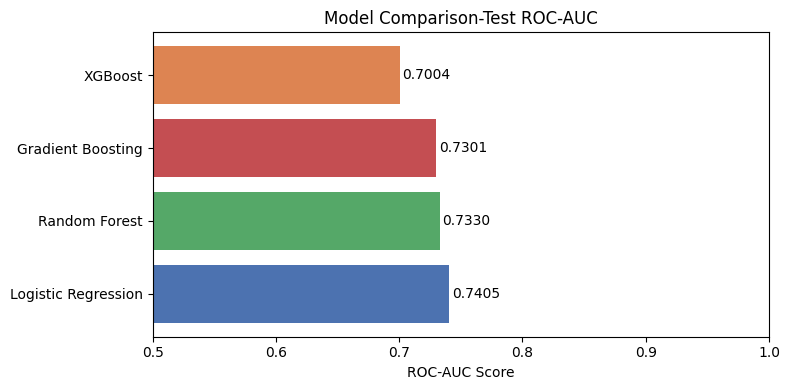

In [ ]:
# Bar chart comparing all models
plt.figure(figsize=(8, 4))
bars = plt.barh(model_list, auc_list, color=['#4C72B0','#55A868','#C44E52','#DD8452'])
plt.xlim(0.5, 1.0)
plt.xlabel('ROC-AUC Score')
plt.title('Model Comparison-Test ROC-AUC')
for bar, auc in zip(bars, auc_list):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{auc:.4f}', va='center')
plt.tight_layout()
plt.show()

## Model Performance Comparison

The bar chart below shows the ROC-AUC score for each model on the test set. Higher is better — a score of 1.0 is perfect prediction, and 0.5 is random guessing. This gives us a quick visual comparison of which algorithm performs best.

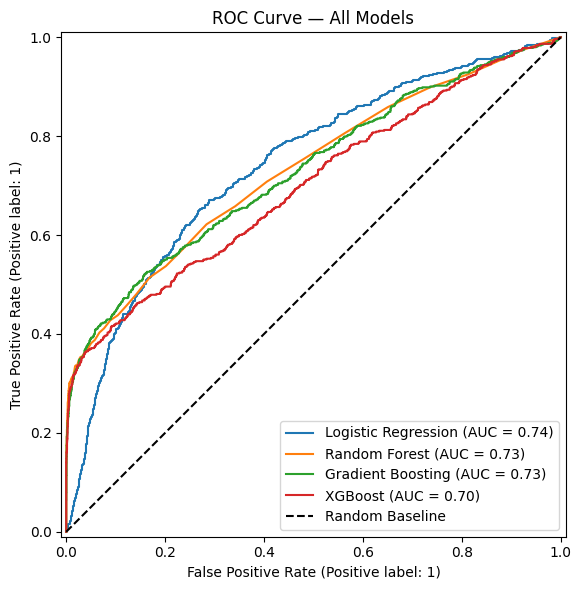

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=f"{name}",
        ax=ax
    )

ax.plot([0,1],[0,1],'k--', label='Random Baseline')
ax.set_title("ROC Curve — All Models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## ROC Curves: Full Picture of Model Performance

The ROC (Receiver Operating Characteristic) curve shows the tradeoff between True Positive Rate and False Positive Rate as we adjust the decision threshold. A curve closer to the top-left corner indicates better performance. All four models are plotted together so we can see which one dominates across all threshold settings.

### Tuning Xgboost

## Hyperparameter Tuning: Making XGBoost Even Better

The best-performing model likely deserves fine-tuning. We'll use grid search with 5-fold cross-validation to find the optimal combination of hyperparameters. This explores different learning rates, tree depths, and regularization strengths to maximize performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [3, 4, 5],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'n_estimators'     : [100, 200, 300],
    'min_child_weight' : [1, 5, 10]
}

xgb_tuned = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42
)

grid = GridSearchCV(
    xgb_tuned, param_grid,
    scoring='roc_auc', cv=5,
    n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV AUC: {grid.best_score_:.4f}")

y_prob_tuned = grid.best_estimator_.predict_proba(X_test)[:, 1]
print(f"Test AUC after tuning: {roc_auc_score(y_test, y_prob_tuned):.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100}
Best CV AUC: 0.7740
Test AUC after tuning: 0.7040


In [ ]:
# Pick best model based on AUC
best_name  = model_list[np.argmax(auc_list)]
best_model = models[best_name]
print(f"Best model: {best_name} with AUC = {max(auc_list):.4f}")

# Score ALL customers (not just test set) for dashboard use
y_prob_all = best_model.predict_proba(model_df[FEATURES].fillna(0))[:, 1]
model_df['Churn_Prob']  = y_prob_all
model_df['Churn_Risk']  = pd.cut(
    model_df['Churn_Prob'],
    bins=[0, 0.15, 0.35, 1.0],
    labels=['Low', 'Medium', 'High']
)

print(f"\nRisk distribution:")
print(model_df['Churn_Risk'].value_counts())

# Save for segmentation and dashboard
model_df.to_csv("Scored_Dataset.csv", index=False)

Best model: Logistic Regression with AUC = 0.7405

Risk distribution:
Churn_Risk
Low       10632
Medium     1860
High       1028
Name: count, dtype: int64


## Final Scoring and Risk Categorization

Now we deploy the best model on **all customers** (not just the test set) to generate churn probability scores. We then bucket these probabilities into three risk categories:

- **Low Risk** (0-15%): Customers unlikely to churn — focus on growth
- **Medium Risk** (15-35%): Customers at moderate risk — targeted retention campaigns
- **High Risk** (>35%): Customers in danger of churning — immediate intervention needed

This scored dataset will power both the dashboard for real-time monitoring and the segmentation analysis to identify customer groups and design targeted strategies.